# 0. EDA (*)
In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the load_dataset method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon.

### a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.



In [158]:
import seaborn as sns
df = sns.load_dataset(name="mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [160]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [161]:
# check what rows have NaN
df[df["horsepower"].isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
32,25.0,4,98.0,NaN,2046,19.0,71,usa,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,usa,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,europe,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,usa,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,europe,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,usa,amc concord dl


In [162]:
# drop Nan value rows
df_drop = df.dropna(subset=["horsepower"])
print(df_drop.shape)

(392, 9)


In [163]:
print(f"{df_drop.shape[0]} samples")
print(f"{df_drop.shape[1] - 1} features")
print("mpg column is our label/target")

392 samples
8 features
mpg column is our label/target


### b) Use describe only on those columns that are relevant to get statistical information from.



In [164]:
# drop irrelevant columns
df_filtered = df_drop.drop(columns=["name", "origin", "acceleration"])
df_filtered.describe()

,mpg,cylinders,displacement,horsepower,weight,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,82.000000


In [165]:
df_filtered.describe().T.drop("count", axis=1)

,mean,std,min,25%,50%,75%,max
mpg,23.445918,7.805007,9.0,17.00,22.75,29.00,46.6
cylinders,5.471939,1.705783,3.0,4.00,4.00,8.00,8.0
displacement,194.411990,104.644004,68.0,105.00,151.00,275.75,455.0
horsepower,104.469388,38.491160,46.0,75.00,93.50,126.00,230.0
weight,2977.584184,849.402560,1613.0,2225.25,2803.50,3614.75,5140.0
model_year,75.979592,3.683737,70.0,73.00,76.00,79.00,82.0


### c) Make some plots on some of the columns that you find interesting.


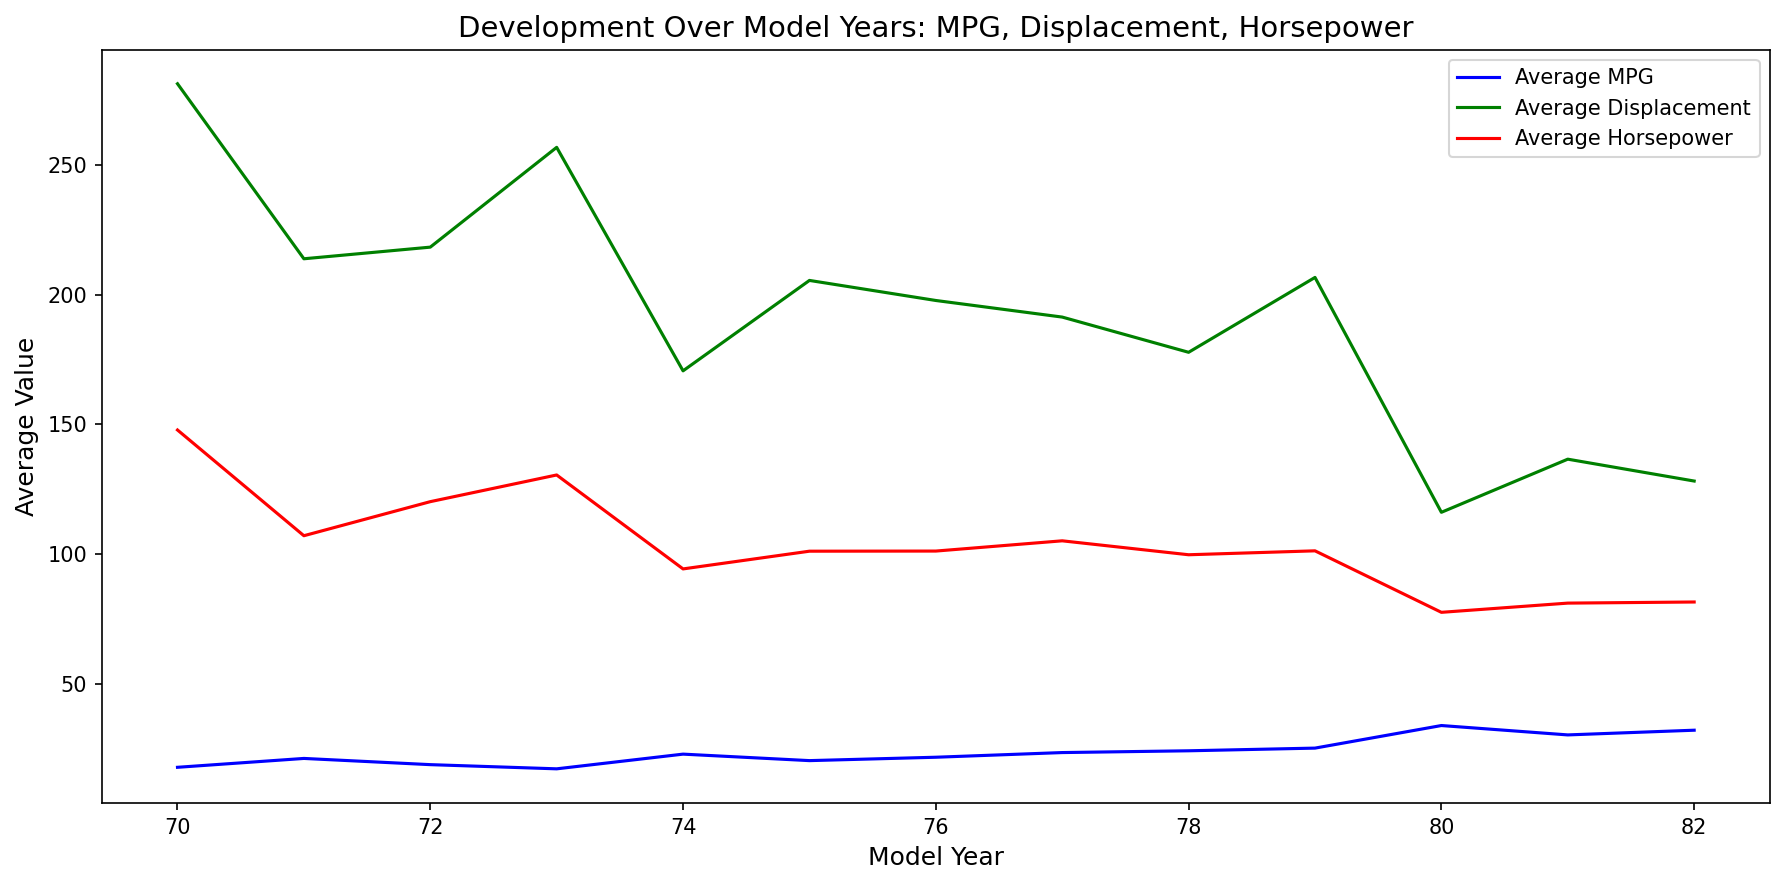

In [166]:
import matplotlib.pyplot as plt 

df_grouped = df_filtered.groupby("model_year").mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
plt.plot(df_grouped["model_year"], df_grouped["mpg"], label="Average MPG", color="blue")
plt.plot(df_grouped["model_year"], df_grouped["displacement"], label="Average Displacement", color="green")
plt.plot(df_grouped["model_year"], df_grouped["horsepower"], label="Average Horsepower", color="red")
# Add labels and title
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("Average Value", fontsize=12)
plt.title("Development Over Model Years: MPG, Displacement, Horsepower", fontsize=14)
plt.legend()
plt.tight_layout()

### d) Check if there are any columns you might want to drop.